# Image Captioning using Deep Learning (BLIP)



## 1. Install libraries


In [5]:
!pip -q uninstall -y pillow pillow-simd

!pip -q install --no-cache-dir --force-reinstall "pillow==11.3.0"

!pip -q install \
transformers \
datasets \
accelerate \
matplotlib \
tqdm \
nltk \
gradio \
evaluate \
sacrebleu \
rouge_score \
sentencepiece \
--upgrade-strategy only-if-needed

!pip -q install --no-deps --force-reinstall "pandas==2.2.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 126.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 108.2 MB/s eta 0:00:00


## 2. Imports and configuration


In [6]:
import os, gc, random, re, math, time
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import BlipProcessor, BlipForConditionalGeneration

import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

nltk.download('punkt', quiet=True)

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)

# Keep small for fast deadline demo. Increase to 500+ for a stronger final result if time allows.
N_EVAL = 100
N_SHOW = 5
OUTPUT_DIR = Path('/content/image_captioning_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

Using device: cuda


## 3. Load Flickr8k dataset


In [7]:
DATASET_NAME = 'jxie/flickr8k'

ds = load_dataset(DATASET_NAME, split='train')
print(ds)
print('Columns:', ds.column_names)
print('First row keys:', ds[0].keys())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
    num_rows: 6000
})
Columns: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4']
First row keys: dict_keys(['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'])


### Helper functions to detect image and caption columns


In [8]:
def detect_image_column(dataset):
    names = dataset.column_names
    preferred = [c for c in names if c.lower() in ['image', 'img', 'picture']]
    if preferred:
        return preferred[0]
    # fallback: check actual object type
    sample = dataset[0]
    for c in names:
        if isinstance(sample[c], Image.Image):
            return c
    raise ValueError(f'Could not detect image column. Columns are: {names}')


def detect_caption_columns(dataset):
    names = dataset.column_names
    caption_cols = [c for c in names if any(k in c.lower() for k in ['caption', 'sentence', 'text'])]
    if caption_cols:
        return caption_cols
    # fallback: string or list-of-string columns
    sample = dataset[0]
    for c in names:
        v = sample[c]
        if isinstance(v, str):
            caption_cols.append(c)
        elif isinstance(v, list) and len(v) > 0 and isinstance(v[0], str):
            caption_cols.append(c)
    if not caption_cols:
        raise ValueError(f'Could not detect caption columns. Columns are: {names}')
    return caption_cols


def get_references(example, caption_cols):
    refs = []
    for c in caption_cols:
        value = example[c]
        if isinstance(value, list):
            refs.extend([str(x).strip() for x in value if str(x).strip()])
        elif isinstance(value, str) and value.strip():
            refs.append(value.strip())
    # Remove duplicates while preserving order
    seen, clean = set(), []
    for r in refs:
        if r not in seen:
            clean.append(r)
            seen.add(r)
    return clean

IMAGE_COL = detect_image_column(ds)
CAPTION_COLS = detect_caption_columns(ds)
print('Detected image column:', IMAGE_COL)
print('Detected caption column(s):', CAPTION_COLS)
print('Sample references:', get_references(ds[0], CAPTION_COLS)[:5])

Detected image column: image
Detected caption column(s): ['caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4']
Sample references: ['A black dog is running after a white dog in the snow .', 'Black dog chasing brown dog through snow', 'Two dogs chase each other across the snowy ground .', 'Two dogs play together in the snow .', 'Two dogs running through a low lying body of water .']


## 4. Create evaluation subset


In [9]:
N_EVAL = min(N_EVAL, len(ds))
eval_ds = ds.shuffle(seed=SEED).select(range(N_EVAL))
print('Evaluation samples:', len(eval_ds))

Evaluation samples: 100


## 5. Load BLIP image captioning model
This is the main project model. BLIP combines a vision encoder with a text decoder for image-to-text generation.

In [10]:
MODEL_NAME = 'Salesforce/blip-image-captioning-base'

processor = BlipProcessor.from_pretrained(MODEL_NAME)
model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)
model.eval()

print('Loaded:', MODEL_NAME)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loaded: Salesforce/blip-image-captioning-base


## 6. Caption generation function


In [12]:
@torch.inference_mode()
def generate_caption(image, num_beams=5, max_new_tokens=35, do_sample=False, top_p=0.9, temperature=1.0):
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    image = image.convert('RGB')
    inputs = processor(images=image, return_tensors='pt').to(DEVICE)
    output_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        num_beams=num_beams,
        do_sample=do_sample,
        top_p=top_p,
        temperature=temperature if do_sample else None,
    )
    caption = processor.decode(output_ids[0], skip_special_tokens=True)
    return caption.strip()

## 7. Qualitative testing on sample images


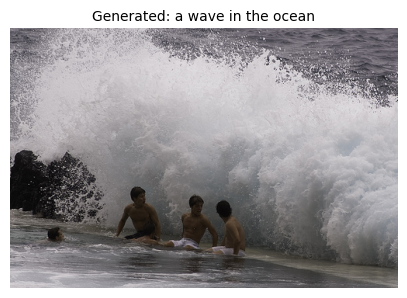

Generated: a wave in the ocean
References:
 - Boys with their backs against an incoming wave .
 - Four boys are about to be hit by an approaching wave .
 - Four people sitting in the path of a wave .
 - Four young men are sitting on the beach under a crashing wave .
 - three boys sitting in sand getting splashed by wave
--------------------------------------------------------------------------------


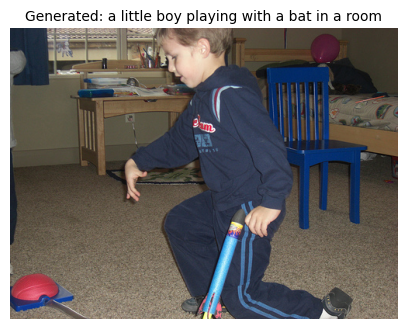

Generated: a little boy playing with a bat in a room
References:
 - A boy in dark blue clothes is kneeling while holding a toy .
 - A boy playing with toys in a bedroom .
 - A boy plays in his bedroom with an air powered rocket .
 - A boy plays with some toys in the house with a blue chair in the background .
 - a young boy wearing a blue outfit playing with a rocket .
--------------------------------------------------------------------------------


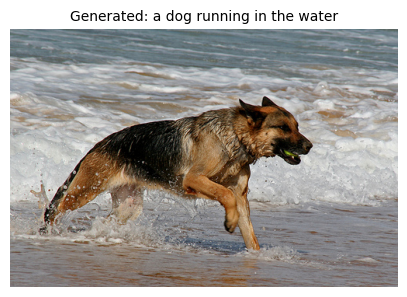

Generated: a dog running in the water
References:
 - A black and brown dog is running out of the surf .
 - A wet dog runs through the surf at a beach .
 - A wet German Shepherd dog is running out of the ocean with a ball in its mouth .
 - German shepherd running in ocean surf
 - The German Shepherd is walking in the body of water .
--------------------------------------------------------------------------------


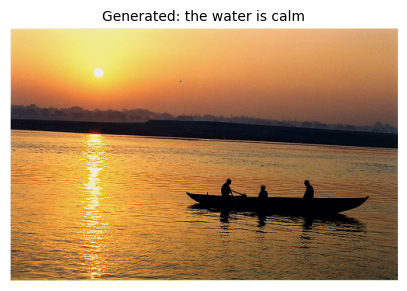

Generated: the water is calm
References:
 - A beautiful sunset with three people in a boat on the lake .
 - As the sunsets 3 people are on a small boat enjoying the view
 - Three people are in a canoe on a calm lake with the sun reflecting yellow .
 - Three people are on a boat in the middle of the water while the sun is in the back .
 - Three people in a boat float on the water at sunset .
--------------------------------------------------------------------------------


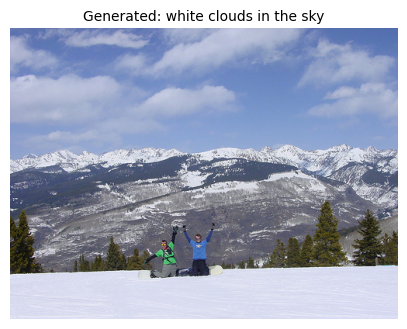

Generated: white clouds in the sky
References:
 - Two men raise their arms atop a snowy mountain .
 - Two people jumping up with snow covered mountains in the background .
 - Two people kneel on the snow and raise their arms with mountains behind them .
 - Two people raise their arms on a snowy hill in the mountains .
 - two snowboarders throw up their hands .
--------------------------------------------------------------------------------


In [27]:
for i in range(min(N_SHOW, len(eval_ds))):
    ex = eval_ds[i]
    img = ex[IMAGE_COL]
    refs = get_references(ex, CAPTION_COLS)
    pred = generate_caption(img, num_beams=5)

    plt.figure(figsize=(5, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Generated: ' + pred, fontsize=10)
    plt.show()

    print('Generated:', pred)
    print('References:')
    for r in refs[:5]:
        print(' -', r)
    print('-' * 80)

## 8. Evaluation metrics: BLEU-1 to BLEU-4


In [14]:
def normalize_text(text):
    text = text.lower().strip()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def tokenize(text):
    return normalize_text(text).split()


def compute_bleu_scores(predictions, references):
    # references: list of list of reference strings
    refs_tok = [[tokenize(r) for r in refs if r.strip()] for refs in references]
    preds_tok = [tokenize(p) for p in predictions]
    smoothie = SmoothingFunction().method4
    scores = {
        'BLEU-1': corpus_bleu(refs_tok, preds_tok, weights=(1, 0, 0, 0), smoothing_function=smoothie),
        'BLEU-2': corpus_bleu(refs_tok, preds_tok, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie),
        'BLEU-3': corpus_bleu(refs_tok, preds_tok, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie),
        'BLEU-4': corpus_bleu(refs_tok, preds_tok, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie),
    }
    return scores

## 9. Compare decoding approaches

1. **Greedy decoding**: fastest, chooses the best next word each step.  
2. **Beam search**: explores multiple candidate captions and usually improves fluency/accuracy.

In [19]:
DECODING_CONFIGS = {
    'BLIP base - Greedy': {'num_beams': 1, 'do_sample': False, 'max_new_tokens': 35},
    'BLIP base - Beam Search': {'num_beams': 5, 'do_sample': False, 'max_new_tokens': 35},
}

all_results = []
summary_rows = []

for approach_name, gen_kwargs in DECODING_CONFIGS.items():
    print('Running:', approach_name)
    predictions = []
    references = []
    image_indices = []

    start = time.time()
    for idx, ex in enumerate(tqdm(eval_ds)):
        img = ex[IMAGE_COL]
        refs = get_references(ex, CAPTION_COLS)
        pred = generate_caption(img, **gen_kwargs)
        predictions.append(pred)
        references.append(refs)
        image_indices.append(idx)
        all_results.append({
            'approach': approach_name,
            'sample_index': idx,
            'prediction': pred,
            'references': ' || '.join(refs),
        })

    elapsed = time.time() - start
    bleu_scores = compute_bleu_scores(predictions, references)
    avg_len = sum(len(tokenize(p)) for p in predictions) / max(1, len(predictions))
    row = {'approach': approach_name, 'samples': len(predictions), 'time_sec': round(elapsed, 2), 'avg_caption_len': round(avg_len, 2)}
    row.update({k: round(v, 4) for k, v in bleu_scores.items()})
    summary_rows.append(row)

results_df = pd.DataFrame(all_results)
summary_df = pd.DataFrame(summary_rows)

results_path = OUTPUT_DIR / 'caption_results.csv'
summary_path = OUTPUT_DIR / 'metrics_summary.csv'
results_df.to_csv(results_path, index=False)
summary_df.to_csv(summary_path, index=False)

print('Metrics summary:')
display(summary_df)
print('Saved:', results_path)
print('Saved:', summary_path)

Running: BLIP base - Greedy


  0%|          | 0/100 [00:00<?, ?it/s]

Running: BLIP base - Beam Search


  0%|          | 0/100 [00:00<?, ?it/s]

Metrics summary:


,approach,samples,time_sec,avg_caption_len,BLEU-1,BLEU-2,BLEU-3,BLEU-4
0,BLIP base - Greedy,100,18.78,6.23,0.6472,0.5075,0.3755,0.2640
1,BLIP base - Beam Search,100,23.87,7.19,0.6456,0.4897,0.3589,0.2611


Saved: /content/image_captioning_outputs/caption_results.csv
Saved: /content/image_captioning_outputs/metrics_summary.csv


## 10. Plot metric comparison


/tmp/ipykernel_775/1235282397.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  ax = plot_df.plot(kind='bar', figsize=(10, 5))


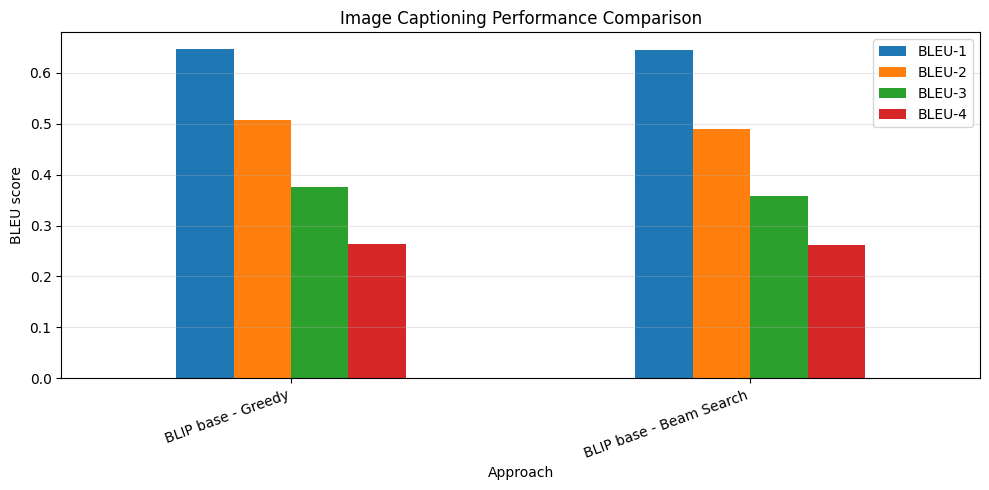

Saved plot: /content/image_captioning_outputs/bleu_comparison.png


In [20]:
plot_df = summary_df.set_index('approach')[['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']]
ax = plot_df.plot(kind='bar', figsize=(10, 5))
plt.title('Image Captioning Performance Comparison')
plt.ylabel('BLEU score')
plt.xlabel('Approach')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plot_path = OUTPUT_DIR / 'bleu_comparison.png'
plt.savefig(plot_path, dpi=200)
plt.show()
print('Saved plot:', plot_path)

## 11.  Final sample predictions table


In [21]:
display(results_df.head(10))

,approach,sample_index,prediction,references
0,BLIP base - Greedy,0,the water is chop,Boys with their backs against an incoming wave...
1,BLIP base - Greedy,1,a young boy playing with a toy,A boy in dark blue clothes is kneeling while h...
2,BLIP base - Greedy,2,a dog running in the water,A black and brown dog is running out of the su...
3,BLIP base - Greedy,3,the water is calm,A beautiful sunset with three people in a boat...
4,BLIP base - Greedy,4,the snow is white,Two men raise their arms atop a snowy mountain...
5,BLIP base - Greedy,5,a man with a black shirt,A man dressed like a rockstar poses in front o...
6,BLIP base - Greedy,6,a dog running in the grass,one brown and white dog chasing a black and wh...
7,BLIP base - Greedy,7,a person jumping in the air on a beach,A child is leaping into the air from a sand du...
8,BLIP base - Greedy,8,a little girl playing with a ball in the grass,A child running outside with a bright colored ...
9,BLIP base - Greedy,9,two people racing motorcycles,two motorcyclist racing around a track || Two ...


## 12. Upload your own image and generate a caption
Run this cell, upload any JPG/PNG image, and the model will caption it.

Saving DL_Proj_Image_2.jpg to DL_Proj_Image_2.jpg


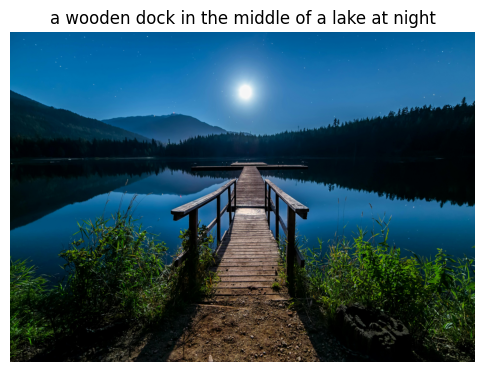

DL_Proj_Image_2.jpg: a wooden dock in the middle of a lake at night


In [25]:
try:
    from google.colab import files
    uploaded = files.upload()
    for filename in uploaded.keys():
        img = Image.open(filename).convert('RGB')
        caption = generate_caption(img, num_beams=5)
        plt.figure(figsize=(6, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(caption)
        plt.show()
        print(f'{filename}: {caption}')
except Exception as e:
    print('Upload cell is intended for Google Colab. Error:', e)

## 13. Optional: Gradio web app demo
This creates a small web interface. In Colab, set `share=True` to get a temporary public link.

In [26]:
import gradio as gr

def caption_image_gradio(image):
    return generate_caption(image, num_beams=5)

demo = gr.Interface(
    fn=caption_image_gradio,
    inputs=gr.Image(type='pil', label='Upload Image'),
    outputs=gr.Textbox(label='Generated Caption'),
    title='Image Captioning using BLIP',
    description='Upload an image and generate an automatic caption using a pretrained BLIP deep learning model.'
)

# In Colab this will give a local link. For a public temporary link, use demo.launch(share=True)
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://22d877b3720c98a5b9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



### Conclusion
This project successfully implements an image captioning system using deep learning. The BLIP model generates meaningful captions for unseen images and is evaluated on Flickr8k using BLEU metrics. The final system includes dataset evaluation, qualitative visualization, custom image inference, and a web demo interface.